# Data-Training Alignment Audit

Visualizes the read-only audit of `data/` (record-tool source of truth) vs `data_training/`
(processed). Run `scripts/audit/audit_data_training_alignment.py` first to populate
`outputs/audit/`. See `DATA_TRAINING_ALIGNMENT_AUDIT_REPORT.md` for the written conclusions.

Headline: the processed data is internally aligned (rows, graphs, timestamps all check out), but
**48 of 73 raw sessions were dropped**, and the dual-task coverage / one-probe-per-window pattern is
**real**, not a timestamp artifact.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

AUDIT = Path('..').resolve() / 'outputs' / 'audit'
def load(name):
    p = AUDIT / name
    return pd.read_csv(p) if p.exists() else pd.DataFrame()
print('audit dir:', AUDIT)
print('files:', sorted(p.name for p in AUDIT.glob('*.csv')))

audit dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\audit
files: ['dual_task_file_candidates.csv', 'dual_task_matching_debug.csv', 'dual_task_matching_mode_summary.csv', 'graph_metadata_alignment.csv', 'probe_count_reality_check.csv', 'processed_metadata_inventory.csv', 'processed_session_summary.csv', 'processed_user_summary.csv', 'raw_session_inventory.csv', 'row_alignment_check.csv', 'session_alignment_summary.csv', 'session_coverage_diff.csv', 'timestamp_alignment_report.csv', 'zero_coverage_user_report.csv']


## Raw vs processed sessions

,0
raw_sessions_count,73
processed_sessions_count,25
sessions_in_raw_not_processed,48
sessions_in_processed_not_raw,0
sessions_in_raw_not_processed_list,session_20260510_191823_9a2425;session_2026051...
sessions_in_processed_not_raw_list,NaN
processed_user_count,10
note,raw sessions expose device_id only; user_id is...



status counts:
 status
missing_from_processed    48
low_dual_task_coverage    16
raw_dual_task_empty        9
Name: count, dtype: int64


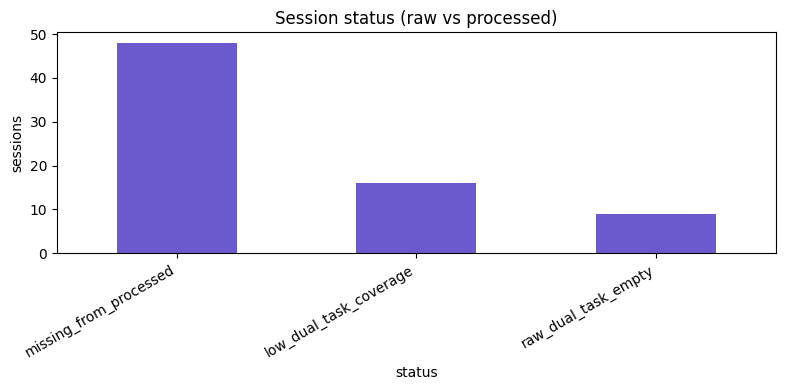

In [2]:
align = load('session_alignment_summary.csv')
display(align.T)
cov = load('session_coverage_diff.csv')
status_counts = cov['status'].value_counts()
print('\nstatus counts:\n', status_counts)
fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='bar', ax=ax, color='slateblue')
ax.set_title('Session status (raw vs processed)'); ax.set_ylabel('sessions')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Dual-task coverage by user

,user_id,processed_windows,raw_dual_task_event_count,match_direct,likely_reason
0,Graja,11,0,0,dual_task.csv present but empty
1,ladabos,16,0,0,dual_task.csv present but empty
2,mohanned,16,0,0,dual_task.csv present but empty


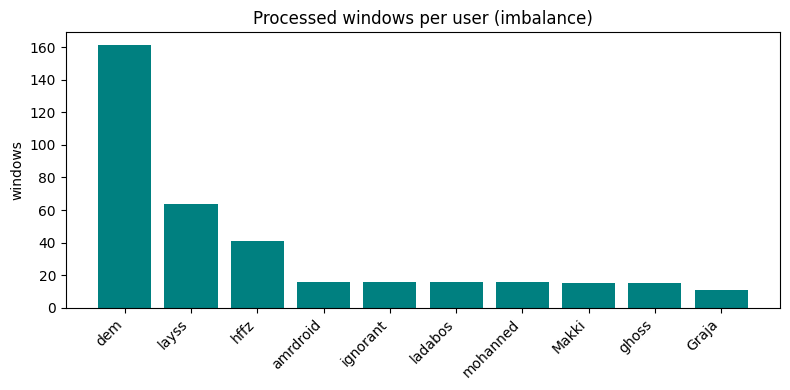

In [3]:
zero = load('zero_coverage_user_report.csv')
display(zero[['user_id','processed_windows','raw_dual_task_event_count','match_direct','likely_reason']])
users = load('processed_user_summary.csv')
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(users['user_id'], users['windows'], color='teal')
ax.set_title('Processed windows per user (imbalance)'); ax.set_ylabel('windows')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## Dual-task coverage by session

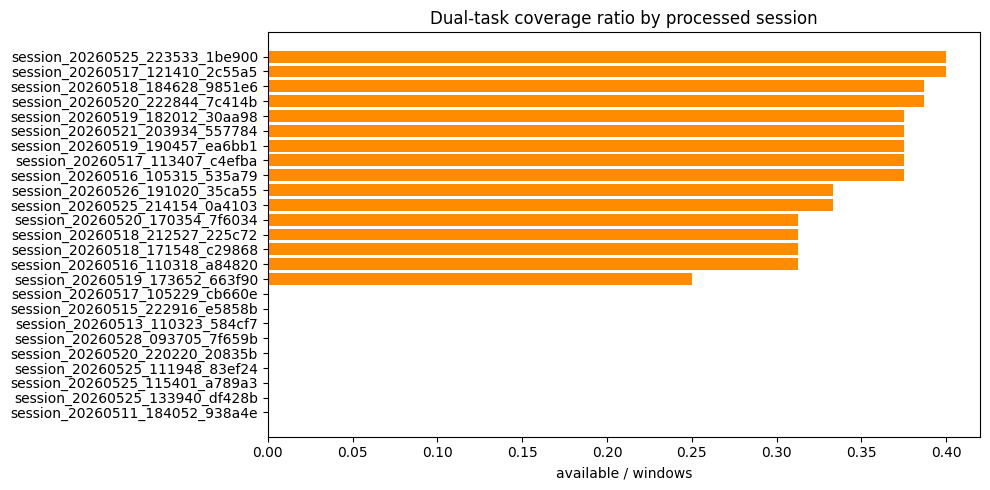

In [4]:
proc = cov[cov['processed_present'] == True].copy()
proc = proc.sort_values('coverage_ratio')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(proc['session_id'], proc['coverage_ratio'], color='darkorange')
ax.set_title('Dual-task coverage ratio by processed session'); ax.set_xlabel('available / windows')
plt.tight_layout(); plt.show()

## Timestamp ranges by session (raw dual-task vs metadata)

suspected_issue counts:
 suspected_issue
none            16
no_dual_task     9
Name: count, dtype: int64


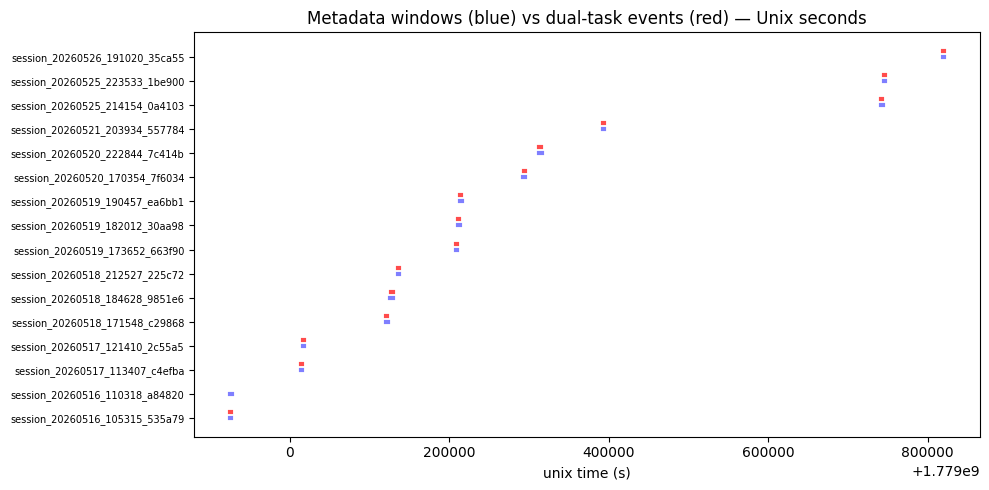

Overlap confirms shared clock (no ms/relative/offset issue).


In [5]:
ts = load('timestamp_alignment_report.csv')
print('suspected_issue counts:\n', ts['suspected_issue'].value_counts())
sub = ts.dropna(subset=['dual_task_ts_min']).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
for i, r in sub.iterrows():
    ax.plot([r['metadata_start_min'], r['metadata_end_max']], [i, i], 'b-', lw=3, alpha=0.5)
    ax.plot([r['dual_task_ts_min'], r['dual_task_ts_max']], [i+0.25, i+0.25], 'r-', lw=3, alpha=0.7)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['session_id'], fontsize=7)
ax.set_title('Metadata windows (blue) vs dual-task events (red) — Unix seconds'); ax.set_xlabel('unix time (s)')
plt.tight_layout(); plt.show()
print('Overlap confirms shared clock (no ms/relative/offset issue).')

## Matching counts by mode

,total_matched
total_current_available,97
total_direct_matched,97
total_ms_matched,0
total_relative_matched,0
total_shifted_to_matched,97
total_shifted_from_matched,97


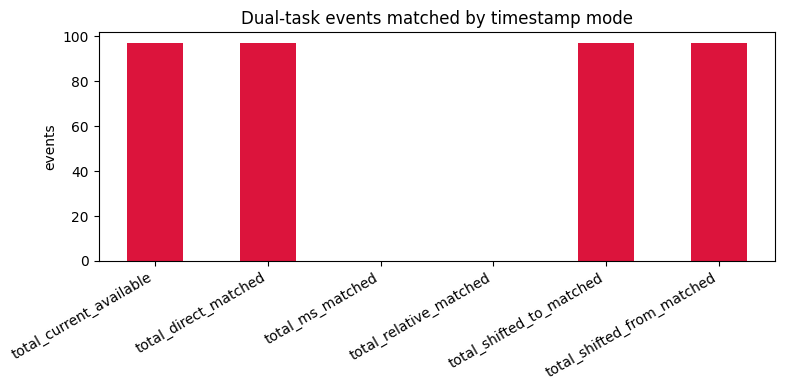

direct == current labels; ms/relative find nothing -> low coverage is real.


In [6]:
mode = load('dual_task_matching_mode_summary.csv').T
mode.columns = ['total_matched']
display(mode)
fig, ax = plt.subplots(figsize=(8, 4))
mode['total_matched'].plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Dual-task events matched by timestamp mode'); ax.set_ylabel('events')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print('direct == current labels; ms/relative find nothing -> low coverage is real.')

## Graph alignment errors

graph_found: 371 / 371
aligned: 371 / 371


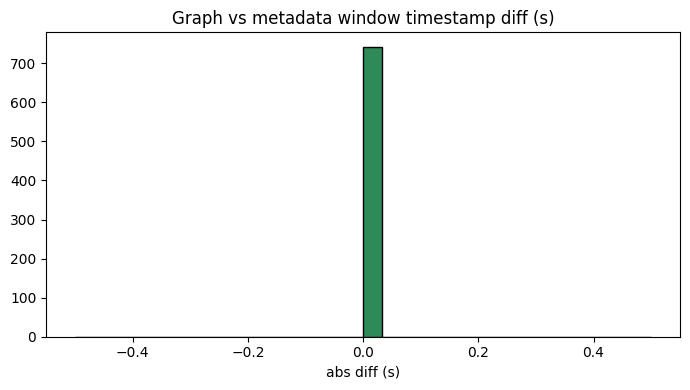

max abs diff: 0.0 -> exact alignment within kept sessions.


In [7]:
g = load('graph_metadata_alignment.csv')
print('graph_found:', int(g['graph_found'].sum()), '/', len(g))
print('aligned:', int(g['aligned'].sum()), '/', len(g))
errs = pd.concat([g['abs_start_diff'], g['abs_end_diff']]).dropna()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(errs, bins=30, color='seagreen', edgecolor='k')
ax.set_title('Graph vs metadata window timestamp diff (s)'); ax.set_xlabel('abs diff (s)')
plt.tight_layout(); plt.show()
print('max abs diff:', float(errs.max()) if len(errs) else 'n/a', '-> exact alignment within kept sessions.')

## Probe-count distribution

,mode,windows_with_0_probes,windows_with_1_probe,windows_with_2plus_probes,max_probes_per_window,mean_probes_per_labelled_window,labelled_windows
0,direct,274,97,0,1,1.0,97
1,ms,371,0,0,0,0.0,0
2,relative,371,0,0,0,0.0,0
3,shifted_to_dual_task_min,274,97,0,1,1.0,97
4,shifted_from_dual_task_min,274,97,0,1,1.0,97


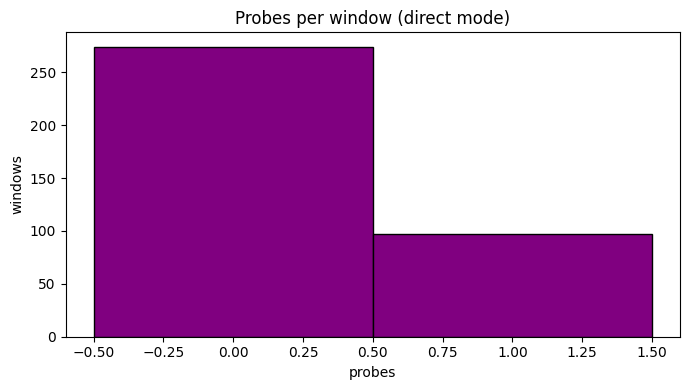

max probes per window = 1 under every mode -> one-probe-per-window is real.


In [8]:
probe = load('probe_count_reality_check.csv')
display(probe)
d = load('dual_task_matching_debug.csv')
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(d['direct_count'], bins=range(0, int(d['direct_count'].max()) + 2), color='purple', edgecolor='k', align='left')
ax.set_title('Probes per window (direct mode)'); ax.set_xlabel('probes'); ax.set_ylabel('windows')
plt.tight_layout(); plt.show()
print('max probes per window = 1 under every mode -> one-probe-per-window is real.')

## Conclusion

- Row / graph / timestamp alignment: **all correct**.
- **48 / 73 raw sessions dropped** (~435 graph windows, ~185 dual-task events lost) → main defect is
  *completeness*, not alignment.
- Low dual-task coverage and one-probe-per-window are **real**; Graja/ladabos/mohanned have **empty**
  raw `dual_task.csv` files.
- **Fix:** investigate why preprocessing dropped sessions, rebuild from the full eligible session set,
  add a `device_id → user_id` map. Do not alter timestamps.